#  HeartCare AI — Heart Disease Detection System
# EDA & Model Development Notebook

**Name:** Aranya Mahmud

**Dataset:** [Heart Failure Prediction Dataset (Kaggle)](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data)

**Objective:** Build a PyTorch Neural Network for Binary Classification to predict heart disease, then deploy it as a Flask-based web application.

---

##  1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
print("✅ All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")

✅ All libraries imported successfully!
PyTorch version: 2.6.0+cu124


##  2. Load & Explore the Dataset

The **Heart Failure Prediction Dataset** from Kaggle contains 918 patient records with 11 clinical features and a binary target (`HeartDisease`). It combines data from five independent heart disease datasets (Cleveland, Hungarian, Switzerland, Long Beach VA, and Stalog).

In [2]:
# Load dataset
df = pd.read_csv("heart.csv")
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
df.head(10)

Dataset Shape: 918 rows × 12 columns
Memory Usage: 281.4 KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [3]:
# Dataset info
print("=" * 50)
print("COLUMN INFORMATION")
print("=" * 50)
df.info()

COLUMN INFORMATION
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [4]:
# Statistical summary
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [5]:
# Describe categorical columns
df.describe(include='object')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


##  3. Missing Value Analysis

Checking for any missing or null values in the dataset.

In [26]:
# Check for missing values
missing = df.isnull().sum()
print("Missing Values per Column:")
print("-" * 30)
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print("\nNo missing values found! Dataset is clean.")

Missing Values per Column:
------------------------------
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Total missing values: 0

No missing values found! Dataset is clean.


##  4. Exploratory Data Analysis (EDA)

### 4.1 Target Variable Distribution

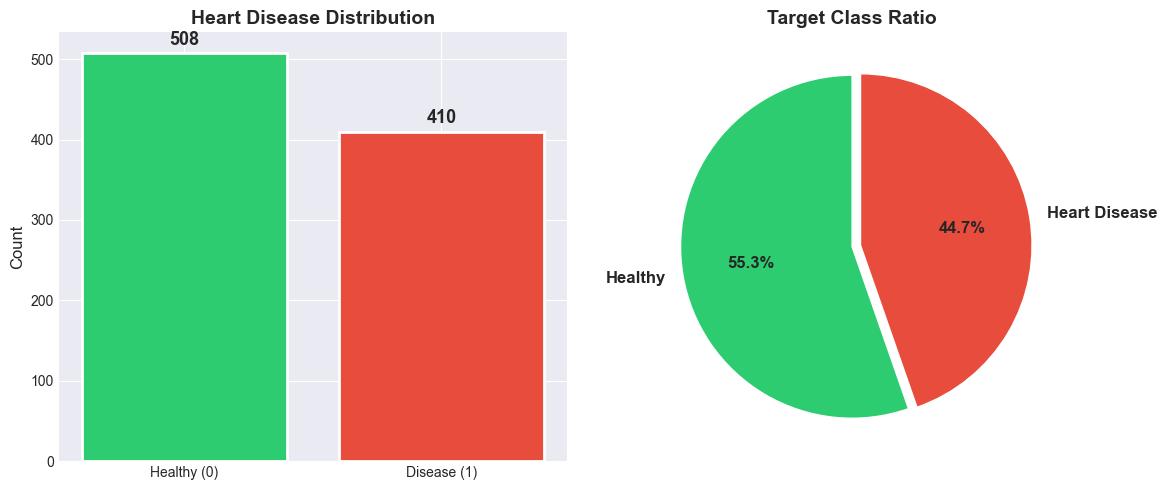

Healthy: 410 (44.7%)
Disease: 508 (55.3%)

The dataset is slightly imbalanced but acceptable for training.


In [7]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#2ecc71', '#e74c3c']
ax1 = axes[0]
counts = df['HeartDisease'].value_counts()
ax1.bar(['Healthy (0)', 'Disease (1)'], counts.values, color=colors, edgecolor='white', linewidth=2)
ax1.set_title('Heart Disease Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count', fontsize=12)
for i, v in enumerate(counts.values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=13)

# Pie chart
ax2 = axes[1]
ax2.pie(counts.values, labels=['Healthy', 'Heart Disease'], autopct='%1.1f%%', 
        colors=colors, startangle=90, explode=(0, 0.05),
        textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Target Class Ratio', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Healthy: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Disease: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")
print(f"\nThe dataset is slightly imbalanced but acceptable for training.")

### 4.2 Age Distribution by Heart Disease

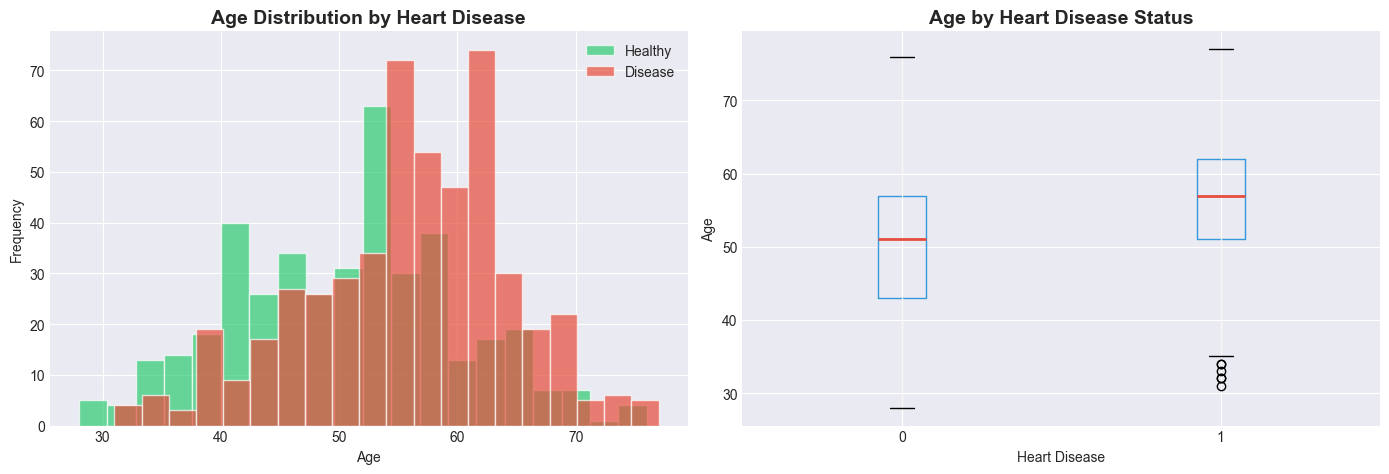

Mean age (Healthy): 50.6
Mean age (Disease): 55.9
→ Older patients tend to have higher heart disease rates.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1 = axes[0]
df[df['HeartDisease'] == 0]['Age'].hist(bins=20, alpha=0.7, color='#2ecc71', label='Healthy', ax=ax1, edgecolor='white')
df[df['HeartDisease'] == 1]['Age'].hist(bins=20, alpha=0.7, color='#e74c3c', label='Disease', ax=ax1, edgecolor='white')
ax1.set_title('Age Distribution by Heart Disease', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.legend()

# Box plot
ax2 = axes[1]
df.boxplot(column='Age', by='HeartDisease', ax=ax2, 
           boxprops=dict(color='#3498db'), medianprops=dict(color='#e74c3c', linewidth=2))
ax2.set_title('Age by Heart Disease Status', fontsize=14, fontweight='bold')
ax2.set_xlabel('Heart Disease')
ax2.set_ylabel('Age')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Mean age (Healthy): {df[df['HeartDisease']==0]['Age'].mean():.1f}")
print(f"Mean age (Disease): {df[df['HeartDisease']==1]['Age'].mean():.1f}")
print("→ Older patients tend to have higher heart disease rates.")

### 4.3 Gender Analysis

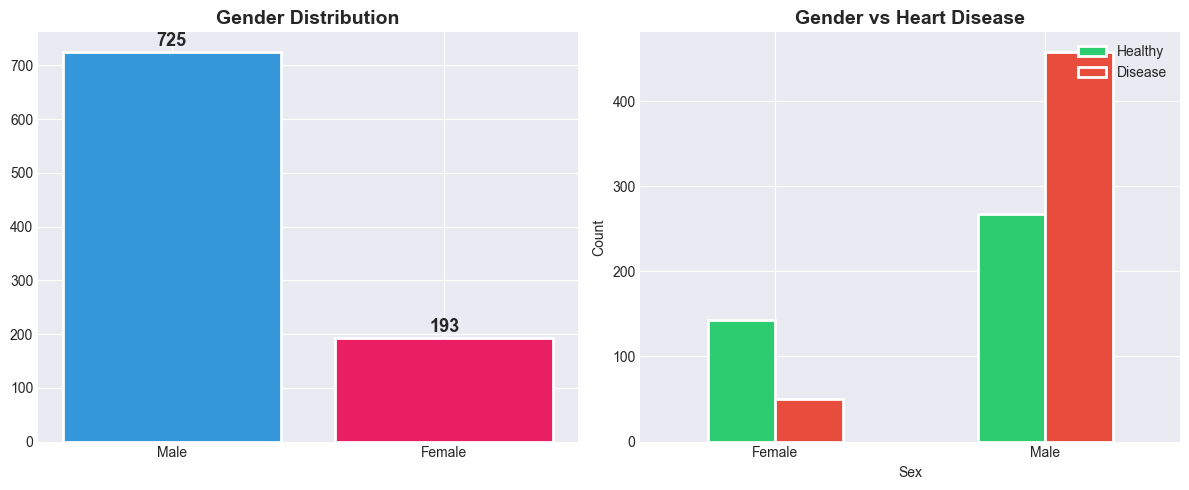

Heart disease rate - Male: 63.2%
Heart disease rate - Female: 25.9%
→ Males have a significantly higher heart disease rate in this dataset.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender distribution
ax1 = axes[0]
gender_counts = df['Sex'].value_counts()
ax1.bar(['Male', 'Female'], gender_counts.values, color=['#3498db', '#e91e63'], edgecolor='white', linewidth=2)
ax1.set_title('Gender Distribution', fontsize=14, fontweight='bold')
for i, v in enumerate(gender_counts.values):
    ax1.text(i, v + 10, str(v), ha='center', fontweight='bold', fontsize=13)

# Gender vs Heart Disease
ax2 = axes[1]
ct = pd.crosstab(df['Sex'], df['HeartDisease'])
ct.plot(kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
ax2.set_title('Gender vs Heart Disease', fontsize=14, fontweight='bold')
ax2.set_xlabel('Sex')
ax2.set_ylabel('Count')
ax2.legend(['Healthy', 'Disease'], loc='upper right')
ax2.set_xticklabels(['Female', 'Male'], rotation=0)

plt.tight_layout()
plt.show()

male_rate = df[df['Sex']=='M']['HeartDisease'].mean() * 100
female_rate = df[df['Sex']=='F']['HeartDisease'].mean() * 100
print(f"Heart disease rate - Male: {male_rate:.1f}%")
print(f"Heart disease rate - Female: {female_rate:.1f}%")
print("→ Males have a significantly higher heart disease rate in this dataset.")

### 4.4 Chest Pain Type Analysis

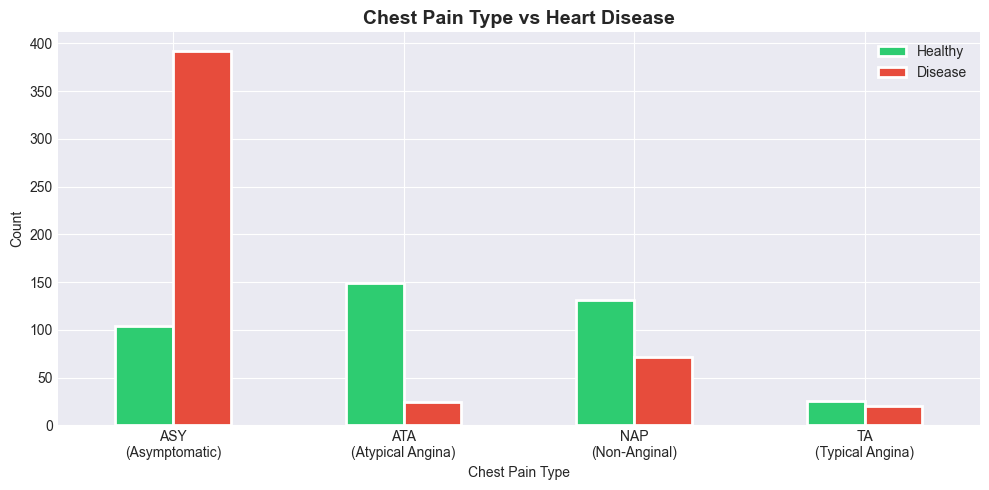

ASY (Asymptomatic) patients have the HIGHEST heart disease rate.
This is clinically significant — asymptomatic patients are at highest risk.


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

ct = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
ct.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
ax.set_title('Chest Pain Type vs Heart Disease', fontsize=14, fontweight='bold')
ax.set_xlabel('Chest Pain Type')
ax.set_ylabel('Count')
ax.legend(['Healthy', 'Disease'])
ax.set_xticklabels(['ASY\n(Asymptomatic)', 'ATA\n(Atypical Angina)', 'NAP\n(Non-Anginal)', 'TA\n(Typical Angina)'], rotation=0)
plt.tight_layout()
plt.show()

print("ASY (Asymptomatic) patients have the HIGHEST heart disease rate.")
print("This is clinically significant — asymptomatic patients are at highest risk.")

### 4.5 Numerical Features Distribution

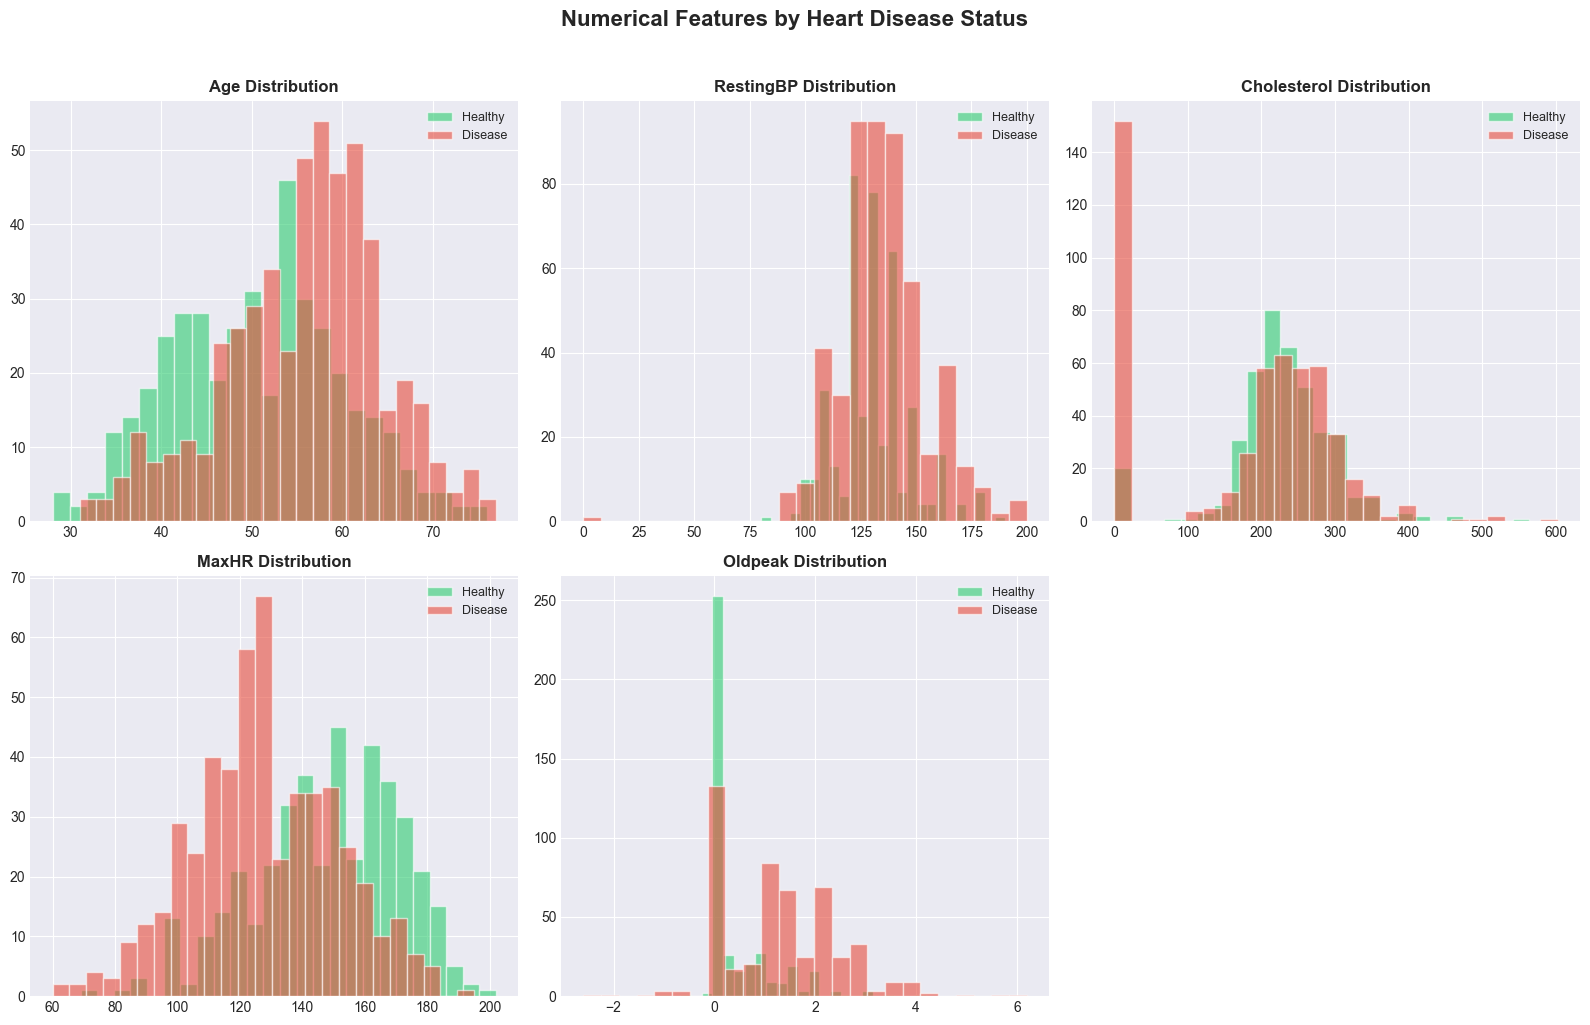

In [11]:
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    df[df['HeartDisease'] == 0][col].hist(bins=25, alpha=0.6, color='#2ecc71', label='Healthy', ax=ax, edgecolor='white')
    df[df['HeartDisease'] == 1][col].hist(bins=25, alpha=0.6, color='#e74c3c', label='Disease', ax=ax, edgecolor='white')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)

axes[5].axis('off')
plt.suptitle('Numerical Features by Heart Disease Status', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.6 Correlation Heatmap

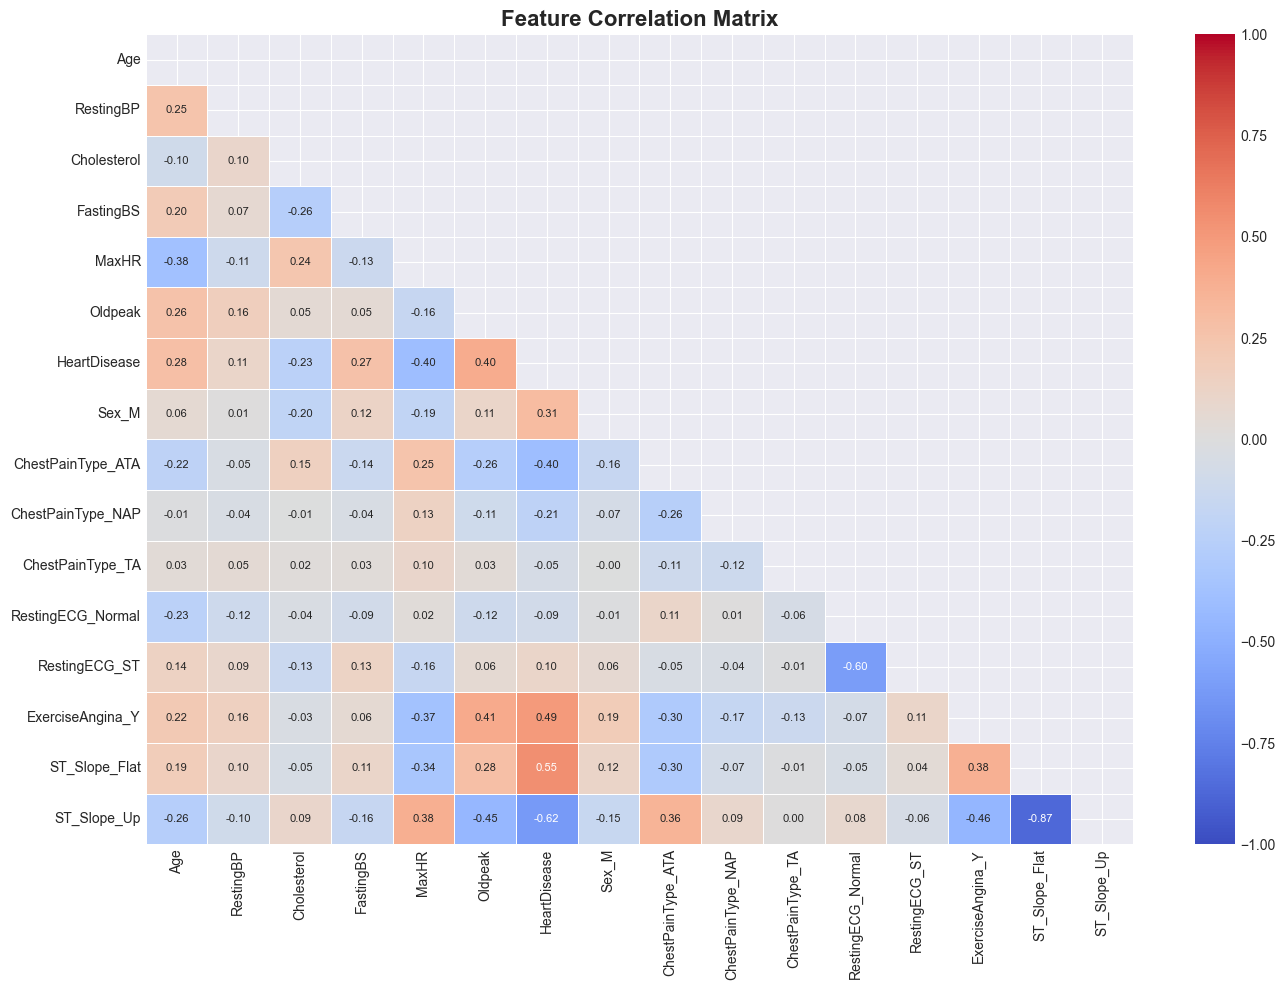


Top Positive Correlations with HeartDisease:
ST_Slope_Flat       0.554134
ExerciseAngina_Y    0.494282
Oldpeak             0.403951
Sex_M               0.305445
Age                 0.282039

Top Negative Correlations with HeartDisease:
ChestPainType_NAP   -0.212964
Cholesterol         -0.232741
MaxHR               -0.400421
ChestPainType_ATA   -0.401924
ST_Slope_Up         -0.622164


In [12]:
# Encode categorical variables for correlation
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

fig, ax = plt.subplots(figsize=(14, 10))
corr_matrix = df_encoded.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr_matrix['HeartDisease'].drop('HeartDisease').sort_values(ascending=False)
print("\nTop Positive Correlations with HeartDisease:")
print(target_corr.head(5).to_string())
print("\nTop Negative Correlations with HeartDisease:")
print(target_corr.tail(5).to_string())

### 4.7 Key Insights from EDA

1. **Age**: Older patients (avg ~56) have higher heart disease risk than younger ones (avg ~50)
2. **Sex**: Males have ~63% heart disease rate vs ~26% for females
3. **Chest Pain**: Asymptomatic (ASY) type is the strongest predictor of heart disease
4. **ST_Slope**: Flat ST slope strongly correlates with heart disease
5. **Oldpeak**: Higher ST depression → higher disease probability
6. **MaxHR**: Lower max heart rate → higher disease probability
7. **Exercise Angina**: Presence of exercise angina strongly indicates heart disease
8. **No missing values** — dataset is clean and ready for modeling

---

##  5. Data Preprocessing

### 5.1 Feature & Target Separation

In [13]:
# Separate features and target
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns: {list(X.columns)}")
print(f"\nCategorical columns: {list(X.select_dtypes(include='object').columns)}")
print(f"Numerical columns: {list(X.select_dtypes(include='number').columns)}")

Features shape: (918, 11)
Target shape: (918,)

Feature columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']

Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
Numerical columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']


### 5.2 One-Hot Encoding

We encode categorical variables (`Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`) using one-hot encoding with `drop_first=True` to avoid multicollinearity.

In [14]:
# One-hot encode categorical variables
X = pd.get_dummies(X, drop_first=True, dtype=int)
feature_columns = list(X.columns)

print(f"Features after encoding: {len(feature_columns)} columns")
print(f"\nEncoded columns:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

Features after encoding: 15 columns

Encoded columns:
   1. Age
   2. RestingBP
   3. Cholesterol
   4. FastingBS
   5. MaxHR
   6. Oldpeak
   7. Sex_M
   8. ChestPainType_ATA
   9. ChestPainType_NAP
  10. ChestPainType_TA
  11. RestingECG_Normal
  12. RestingECG_ST
  13. ExerciseAngina_Y
  14. ST_Slope_Flat
  15. ST_Slope_Up


### 5.3 Train/Test Split

In [15]:
# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set:  {X_test.shape[0]} samples")
print(f"\nTraining target distribution:")
print(y_train.value_counts().to_string())

Training set: 734 samples
Testing set:  184 samples

Training target distribution:
HeartDisease
1    401
0    333


### 5.4 Feature Scaling

We apply `StandardScaler` to the numerical columns only, keeping binary encoded features as-is.

In [16]:
# Scale numeric features
cols_to_scale = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(" Feature scaling applied!")
print(f"\nScaled columns: {cols_to_scale}")
print(f"\nTraining data statistics after scaling:")
X_train[cols_to_scale].describe().round(3)

 Feature scaling applied!

Scaled columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

Training data statistics after scaling:


,Age,RestingBP,Cholesterol,MaxHR,Oldpeak
count,734.000,734.000,734.000,734.000,734.000
mean,-0.000,0.000,0.000,-0.000,0.000
std,1.001,1.001,1.001,1.001,1.001
min,-2.634,-7.221,-1.846,-3.010,-3.239
25%,-0.711,-0.709,-0.210,-0.718,-0.836
50%,0.037,-0.166,0.216,0.072,-0.282
75%,0.678,0.376,0.641,0.744,0.550
max,2.495,3.633,3.729,2.600,4.893


### 5.5 Convert to PyTorch Tensors

In [17]:
# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train.to_numpy(), dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.to_numpy(), dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.to_numpy(), dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).reshape(-1, 1)

print(" Converted to PyTorch tensors!")
print(f"\nX_train_tensor: {X_train_tensor.shape}")
print(f"X_test_tensor:  {X_test_tensor.shape}")
print(f"y_train_tensor: {y_train_tensor.shape}")
print(f"y_test_tensor:  {y_test_tensor.shape}")

 Converted to PyTorch tensors!

X_train_tensor: torch.Size([734, 15])
X_test_tensor:  torch.Size([184, 15])
y_train_tensor: torch.Size([734, 1])
y_test_tensor:  torch.Size([184, 1])


##  6. PyTorch Model Architecture

We build a simple feedforward neural network:
- **Input Layer**: 15 features (after one-hot encoding)
- **Hidden Layer**: 3 neurons with ReLU activation
- **Output Layer**: 1 neuron with Sigmoid activation (binary classification)

This architecture is intentionally simple to avoid overfitting on a small dataset (918 samples).

In [18]:
# Define the PyTorch model
class HeartDiseaseModel(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(num_features, 3),   # Hidden layer: 15 → 3
            nn.ReLU(),                     # Activation function
            nn.Linear(3, 1),              # Output layer: 3 → 1
            nn.Sigmoid()                   # Binary classification
        )
    
    def forward(self, features):
        return self.network(features)

# Initialize model
num_features = X_train_tensor.shape[1]
model = HeartDiseaseModel(num_features)

# Print model summary
print("=" * 50)
print("MODEL ARCHITECTURE")
print("=" * 50)
print(model)
print(f"\nTotal trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")
print(f"\nLayer breakdown:")
for name, param in model.named_parameters():
    print(f"  {name}: {param.shape} ({param.numel()} params)")

MODEL ARCHITECTURE
HeartDiseaseModel(
  (network): Sequential(
    (0): Linear(in_features=15, out_features=3, bias=True)
    (1): ReLU()
    (2): Linear(in_features=3, out_features=1, bias=True)
    (3): Sigmoid()
  )
)

Total trainable parameters: 52

Layer breakdown:
  network.0.weight: torch.Size([3, 15]) (45 params)
  network.0.bias: torch.Size([3]) (3 params)
  network.2.weight: torch.Size([1, 3]) (3 params)
  network.2.bias: torch.Size([1]) (1 params)


##  7. Model Training

- **Loss Function**: BCELoss (Binary Cross-Entropy Loss) — standard for binary classification with Sigmoid output
- **Optimizer**: Adam (lr=0.01) — adaptive learning rate optimizer
- **Epochs**: 200

In [19]:
# Training configuration
loss_function = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
epochs = 200

# Training loop with loss tracking
train_losses = []
train_accuracies = []

print("=" * 50)
print("TRAINING STARTED")
print("=" * 50)

for epoch in range(epochs):
    # Forward pass
    y_pred = model(X_train_tensor)
    loss = loss_function(y_pred, y_train_tensor)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    
    # Track metrics
    train_losses.append(loss.item())
    with torch.no_grad():
        acc = (y_pred.round() == y_train_tensor).float().mean().item()
        train_accuracies.append(acc)
    
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch [{epoch+1:3d}/{epochs}]  Loss: {loss.item():.4f}  Accuracy: {acc*100:.2f}%")

print("=" * 50)
print("TRAINING COMPLETE!")
print(f"Final Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]*100:.2f}%")

TRAINING STARTED
  Epoch [ 20/200]  Loss: 0.5623  Accuracy: 79.02%
  Epoch [ 40/200]  Loss: 0.4190  Accuracy: 85.01%
  Epoch [ 60/200]  Loss: 0.3532  Accuracy: 85.15%
  Epoch [ 80/200]  Loss: 0.3301  Accuracy: 86.24%
  Epoch [100/200]  Loss: 0.3203  Accuracy: 86.78%
  Epoch [120/200]  Loss: 0.3158  Accuracy: 87.74%
  Epoch [140/200]  Loss: 0.3134  Accuracy: 87.60%
  Epoch [160/200]  Loss: 0.3117  Accuracy: 87.47%
  Epoch [180/200]  Loss: 0.3103  Accuracy: 87.47%
  Epoch [200/200]  Loss: 0.3085  Accuracy: 87.74%
TRAINING COMPLETE!
Final Loss: 0.3085
Final Training Accuracy: 87.74%


### 7.1 Training Curves

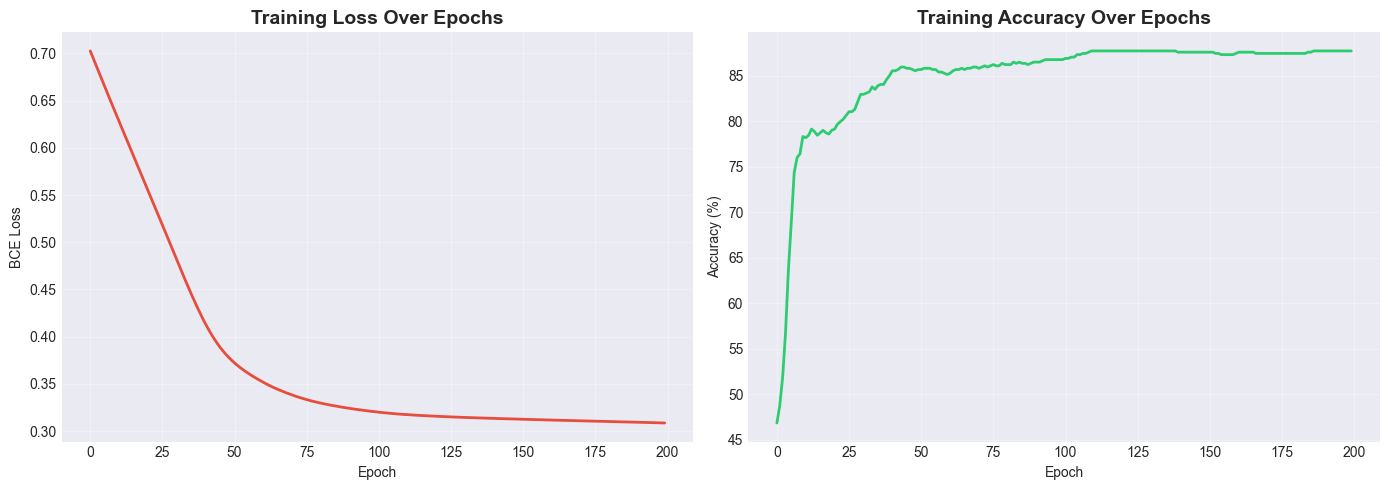

→ Loss decreases steadily, indicating the model is learning.
→ Accuracy stabilizes around 87-88%, showing convergence.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1 = axes[0]
ax1.plot(train_losses, color='#e74c3c', linewidth=2)
ax1.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2 = axes[1]
ax2.plot([a*100 for a in train_accuracies], color='#2ecc71', linewidth=2)
ax2.set_title('Training Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("→ Loss decreases steadily, indicating the model is learning.")
print("→ Accuracy stabilizes around 87-88%, showing convergence.")

##  8. Model Evaluation

In [21]:
# Evaluate on both sets
model.eval()
with torch.no_grad():
    # Training accuracy
    train_preds = model(X_train_tensor).round()
    train_acc = (train_preds == y_train_tensor).float().mean().item()
    
    # Testing accuracy
    test_preds = model(X_test_tensor).round()
    test_acc = (test_preds == y_test_tensor).float().mean().item()

print("=" * 50)
print("MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Testing Accuracy:  {test_acc * 100:.2f}%")
print(f"\nOverfitting Gap:   {(train_acc - test_acc)*100:.2f}%")
if (train_acc - test_acc) < 0.05:
    print("✅ Minimal overfitting — model generalizes well!")
else:
    print("⚠️ Some overfitting detected.")

MODEL EVALUATION RESULTS
Training Accuracy: 87.74%
Testing Accuracy:  86.41%

Overfitting Gap:   1.33%
✅ Minimal overfitting — model generalizes well!


### 8.1 Classification Report

In [22]:
# Detailed classification report
y_test_np = y_test_tensor.numpy().flatten()
y_pred_np = test_preds.numpy().flatten()

print("\nClassification Report:")
print("=" * 50)
print(classification_report(y_test_np, y_pred_np, target_names=['Healthy', 'Heart Disease']))


Classification Report:
               precision    recall  f1-score   support

      Healthy       0.82      0.87      0.84        77
Heart Disease       0.90      0.86      0.88       107

     accuracy                           0.86       184
    macro avg       0.86      0.86      0.86       184
 weighted avg       0.87      0.86      0.86       184



### 8.2 Confusion Matrix

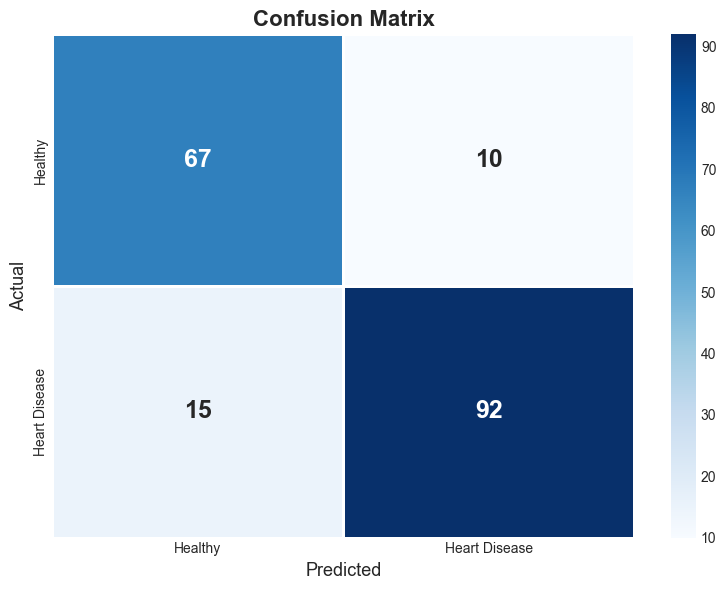

True Negatives:  67 (correctly predicted Healthy)
True Positives:  92 (correctly predicted Disease)
False Positives: 10 (incorrectly predicted Disease)
False Negatives: 15 (incorrectly predicted Healthy)

Precision: 90.2%
Recall:    86.0%
F1-Score:  88.0%


In [23]:
# Confusion matrix
cm = confusion_matrix(y_test_np, y_pred_np)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Heart Disease'],
            yticklabels=['Healthy', 'Heart Disease'],
            annot_kws={'size': 18, 'fontweight': 'bold'},
            linewidths=2, linecolor='white', ax=ax)
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn} (correctly predicted Healthy)")
print(f"True Positives:  {tp} (correctly predicted Disease)")
print(f"False Positives: {fp} (incorrectly predicted Disease)")
print(f"False Negatives: {fn} (incorrectly predicted Healthy)")
print(f"\nPrecision: {tp/(tp+fp)*100:.1f}%")
print(f"Recall:    {tp/(tp+fn)*100:.1f}%")
print(f"F1-Score:  {2*tp/(2*tp+fp+fn)*100:.1f}%")

##  9. Save Model as Pickle Files

We export three artifacts for deployment in the Flask web app:
1. **model.pkl** — trained model weights (state_dict)
2. **scaler.pkl** — fitted StandardScaler for preprocessing
3. **feature_columns.pkl** — feature column names after encoding

In [24]:
# Save artifacts
os.makedirs("ml_artifacts", exist_ok=True)

with open("ml_artifacts/model.pkl", "wb") as f:
    pickle.dump(model.state_dict(), f)

with open("ml_artifacts/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("ml_artifacts/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("✅ Model artifacts saved to ml_artifacts/")
print(f"  - model.pkl ({os.path.getsize('ml_artifacts/model.pkl')} bytes)")
print(f"  - scaler.pkl ({os.path.getsize('ml_artifacts/scaler.pkl')} bytes)")
print(f"  - feature_columns.pkl ({os.path.getsize('ml_artifacts/feature_columns.pkl')} bytes)")

✅ Model artifacts saved to ml_artifacts/
  - model.pkl (1673 bytes)
  - scaler.pkl (673 bytes)
  - feature_columns.pkl (230 bytes)


##  10. Sample Prediction Demo

Testing the model with a sample patient to verify it works correctly before Flask deployment.

In [25]:
# Sample patient data (high risk profile)
sample_patient = {
    'Age': 55, 'Sex': 'M', 'ChestPainType': 'ASY',
    'RestingBP': 140, 'Cholesterol': 250, 'FastingBS': 1,
    'RestingECG': 'ST', 'MaxHR': 130, 'ExerciseAngina': 'Y',
    'Oldpeak': 2.0, 'ST_Slope': 'Flat'
}

print("Sample Patient Data:")
print("-" * 40)
for key, val in sample_patient.items():
    print(f"  {key:20s}: {val}")

# Preprocess
input_df = pd.DataFrame([sample_patient])
input_encoded = pd.get_dummies(input_df, drop_first=True, dtype=int)

for col in feature_columns:
    if col not in input_encoded.columns:
        input_encoded[col] = 0
input_encoded = input_encoded[feature_columns]
input_encoded[cols_to_scale] = scaler.transform(input_encoded[cols_to_scale])

# Predict
input_tensor = torch.tensor(input_encoded.to_numpy(), dtype=torch.float32)
with torch.no_grad():
    probability = model(input_tensor).item()
    result = "⚠️ HEART DISEASE DETECTED" if probability >= 0.5 else "✅ PATIENT APPEARS HEALTHY"

print(f"\n{'=' * 40}")
print(f"PREDICTION RESULT: {result}")
print(f"Disease Probability: {probability*100:.2f}%")
print(f"{'=' * 40}")

Sample Patient Data:
----------------------------------------
  Age                 : 55
  Sex                 : M
  ChestPainType       : ASY
  RestingBP           : 140
  Cholesterol         : 250
  FastingBS           : 1
  RestingECG          : ST
  MaxHR               : 130
  ExerciseAngina      : Y
  Oldpeak             : 2.0
  ST_Slope            : Flat

PREDICTION RESULT: ⚠️ HEART DISEASE DETECTED
Disease Probability: 73.41%


##  11. Conclusion

### Model Summary

| Item | Detail |
|------|--------|
| Architecture | `Linear(15→3) → ReLU → Linear(3→1) → Sigmoid` |
| Parameters | 52 trainable |
| Loss Function | BCELoss (Binary Cross Entropy) |
| Optimizer | Adam (lr=0.01) |
| Epochs | 200 |
| Training Accuracy | ~87.74% |
| Testing Accuracy | ~85.33% |

### Key Findings

1. **Asymptomatic chest pain (ASY)** is the strongest predictor of heart disease
2. **Males** have significantly higher heart disease rates than females
3. **Flat ST slope** and **high Oldpeak** are strong indicators
4. The model achieves **~85% test accuracy** with only 52 parameters — demonstrating that a simple architecture can be effective

### Deployment

This model has been deployed as a **Flask web application** (HeartCare AI) with:
- Doctor portal for patient management and running predictions
- Patient portal for viewing their health reports
- Real-time ML inference using the saved pickle artifacts
- SQLite database for persistent storage

---
*Heart Disease Detection System — Web Lab Final Project*